# **Travaux pratiques 1 : régression pour l'estimation du prix des biens immobiliers**

**Problématique & Objectif**

Dans cette séance, nous allons traiter un problème d'**estimation de prix de biens immobiliers**. Notre objectif principal sera d'obtenir un modèle prédictif du prix médian d'un bien à partir d'un ensemble de caractéristiques qui décrivent le bien en question et son environnement.

Vous travaillerez avec un jeu de données contenant des informations détaillées. Parmi ces informations, vous trouverez :

- Des indicateurs socio-économiques de la zone (ex: revenu médian des ménages, population).
- Des caractéristiques propres aux biens immobiliers (ex: âge médian des habitations, nombre moyen de pièces par foyer).
- Des informations de localisation géographique (latitude, longitude).

Dans ce jeu de données, vous y rencontrerez des valeurs manquantes, des valeurs aberrantes (*outliers*) et des incohérences qui nécessiteront votre attention.

Ce TP est conçu pour vous guider pas à pas à travers les étapes essentielles de tout projet de Machine Learning :

- Chargement et exploration des données pour en comprendre la structure et identifier les problèmes.
- Nettoyage et préparation des données pour les rendre utilisables par un algorithme de machine learning.
- Entraînement d'un modèle de régression linéaire.
- Évaluation des performances de ce modèle.

À chaque étape, des indications claires vous seront fournies, y compris sur les fonctions *scikit-learn* (*sklearn*) à utiliser, afin de faciliter votre apprentissage et votre prise en main des outils.

# **Étape 1 : chargement et exploration des données**

Dans cette première partie, vous allez apprendre à charger un jeu de données puis à effectuer une première exploration pour comprendre sa structure, son contenu et identifier les problèmes que comporte ce type de données.

Ce TP peut être réalisé dans **Google Colab** (avec un fichier stocké sur **Google Drive**) ou en local avec **Jupyter Notebook**.

Les instructions ci-dessous montrent les deux méthodes. Suivez uniquement celle qui correspond à votre environnement.

**Objectifs de cette partie** :

- Monter votre Google Drive (si vous utilisez Google Colab).
- Charger le dataset `california_housing.csv`.
- Obtenir un aperçu global des données (structure, types, premières lignes).
- Identifier les valeurs manquantes (NaNs).
- Repérer visuellement les valeurs aberrantes (outliers) dans les variables numériques.

In [13]:
# Import des bibliothèques utiles
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Pour les prochaines étapes de préparation
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

# Configuration de l'affichage pour Pandas (optionnel mais utile)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)


# **Étape 1.1 : chargement du jeu de données**
Le fichier `california_housing.csv` contient les variables suivantes :

Voici une description des variables contenues dans le jeu de données :
- **MedInc** : revenu médian des ménages dans le quartier.
- **HouseAge** : âge médian des maisons dans le quartier.
- **AveRooms** : nombre moyen de pièces par ménage.
- **AveBedrms** : nombre moyen de chambres par ménage.
- **Population** : population totale du quartier.
- **AveOccup** : nombre moyen de personnes par ménage.
- **Latitude** : latitude du quartier.
- **Longitude** : longitude du quartier.
- **MedHouseVal** : valeur médiane des maisons dans le quartier (en centaines de milliers de dollars).

In [14]:
# Définir le chemin vers votre fichier

# ==================================================
# CAS 1 : Google Colab (fichier dans Google Drive)
# ==================================================
# Remplacez 'ML_Datasets' par le nom de votre dossier si nécessaire

file_path = 'C:\\Users\\julie\\OneDrive\\Documents\\Scolaire\\INFRES 2\\Machine Learning\\california_housing.csv'

# ==================================================
# CAS 2 : Travail en local (Jupyter Notebook)
# ==================================================
# Placez simplement le fichier california_housing.csv
# dans le même dossier que votre notebook

# file_path = "california_housing.csv"

# Vérifiez si le fichier existe
if not os.path.exists(file_path):
    print(f"Erreur : Le fichier '{file_path}' est introuvable.")
    print("Veuillez vérifier que Google Drive est bien monté et que le chemin du fichier est correct.")
else:
    print(f"Chargement du dataset depuis '{file_path}'...")
    # Utilisez pd.read_csv pour charger les données
    # Si des virgules avaient été utilisées, il faudrait ajouter decimal=','
    df = pd.read_csv(file_path)
    print("Dataset chargé avec succès.")

    # Afficher les 5 premières lignes du DataFrame pour un premier aperçu
    print("\n--- Aperçu des 5 premières lignes du dataset ---")
    print(df.head())

    # Afficher la taille du DataFrame (nombre de lignes, nombre de colonnes)
    print(f"\n--- Taille du dataset : {df.shape[0]} lignes, {df.shape[1]} colonnes ---")

Chargement du dataset depuis 'C:\Users\julie\OneDrive\Documents\Scolaire\INFRES 2\Machine Learning\california_housing.csv'...
Dataset chargé avec succès.

--- Aperçu des 5 premières lignes du dataset ---
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  Longitude  MedHouseVal
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88    -122.23        4.526
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86    -122.22        3.585
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85    -122.24        3.521
3  5.6431       NaN  5.817352   1.073059       558.0  2.547945     37.85    -122.25        3.413
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85    -122.25        3.422

--- Taille du dataset : 20640 lignes, 9 colonnes ---


# **Étape 1.2 : exploration du jeu de données**
La fonction `.info()` de Pandas est utile pour obtenir un résumé rapide des informations du DataFrame, y compris les types de données de chaque colonne et le nombre de valeurs non-nulles. Cela permet d'identifier rapidement les colonnes contenant des valeurs manquantes.

La fonction `.describe()` fournit des statistiques descriptives pour les colonnes numériques, ce qui peut donner des indices sur la présence d'outliers.

In [15]:
print("\n--- Informations générales sur le dataset (df.info()) ---")
# TODO: Utilisez df.info() pour afficher les informations générales
# Anaylsez la sortie : Quels sont les types de données ? Quelles colonnes ont moins de 20640 valeurs non-nulles ?
df.info()


print("\n--- Statistiques descriptives des colonnes numériques (df.describe()) ---")
# TODO: Utilisez df.describe() pour afficher les statistiques descriptives
# Anaylsez la sortie : Prêtez attention aux min/max, moyennes et quartiles. Des valeurs vous paraissent-elles anormales ?
df.describe()


--- Informations générales sur le dataset (df.info()) ---
<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20438 non-null  float64
 1   HouseAge     20434 non-null  float64
 2   AveRooms     20434 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB

--- Statistiques descriptives des colonnes numériques (df.describe()) ---


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20438.000000,20434.000000,20434.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,4.584062,28.643682,5.430462,1.096675,1632.782017,3.070655,35.631861,-119.569704,2.068558
std,7.442992,12.587610,2.483180,0.473911,3106.735281,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.573950,18.000000,4.440930,1.006079,792.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.553400,29.000000,5.229872,1.048780,1173.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.797900,37.000000,6.052786,1.099526,1751.000000,3.282261,37.710000,-118.010000,2.647250
max,99.775847,52.000000,141.909091,34.066667,213320.620276,1243.333333,41.950000,-114.310000,5.000010


# **Étape 1.3 : identification des problèmes dans le jeu de données**

Nous allons maintenant examiner plus en profondeur les problèmes présents dans ce jeu de données : les valeurs manquantes et les valeurs aberrantes.

**Problème 1 : Identification et quantification des valeurs manquantes (NaNs)**

Les valeurs manquantes peuvent biaiser les analyses et empêcher le bon fonctionnement de nombreux algorithmes de Machine Learning. Il est essentiel de les identifier avant de les traiter.

**Tâche** : Utilisez la méthode appropriée pour compter le nombre de valeurs manquantes par variable (colonne).

In [16]:
print("\n--- Nombre de valeurs manquantes par colonne (NaNs) ---")
# TODO: Utilisez df.isnull() combiné avec .sum() pour compter les NaNs par colonne
# Quelles sont les variables les plus affectées ?
df.isnull().sum()


--- Nombre de valeurs manquantes par colonne (NaNs) ---



--- Nombre de valeurs manquantes par colonne (NaNs) ---


MedInc         202
HouseAge       206
AveRooms       206
AveBedrms        0
Population       0
AveOccup         0
Latitude         0
Longitude        0
MedHouseVal      0
dtype: int64

**Problème 2 : Détection des valeurs aberrantes (outliers) dans les variables numériques**

Les valeurs aberrantes (outliers) peuvent fortement influencer les performances des modèles de régression. Il est donc important de les identifier lors de la phase d’exploration des données. Les visualisations statistiques, comme les box plots, constituent un moyen simple et efficace pour observer la distribution des variables numériques et détecter la présence éventuelle de valeurs aberrantes.

**Tâche :** Créez des box plots pour les variables (MedInc, Population) afin de visualiser leur distribution et de repérer les outliers.


--- Visualisation des valeurs aberrantes (Outliers) dans TOUTES les colonnes numériques ---



--- Visualisation des valeurs aberrantes (Outliers) dans TOUTES les colonnes numériques ---


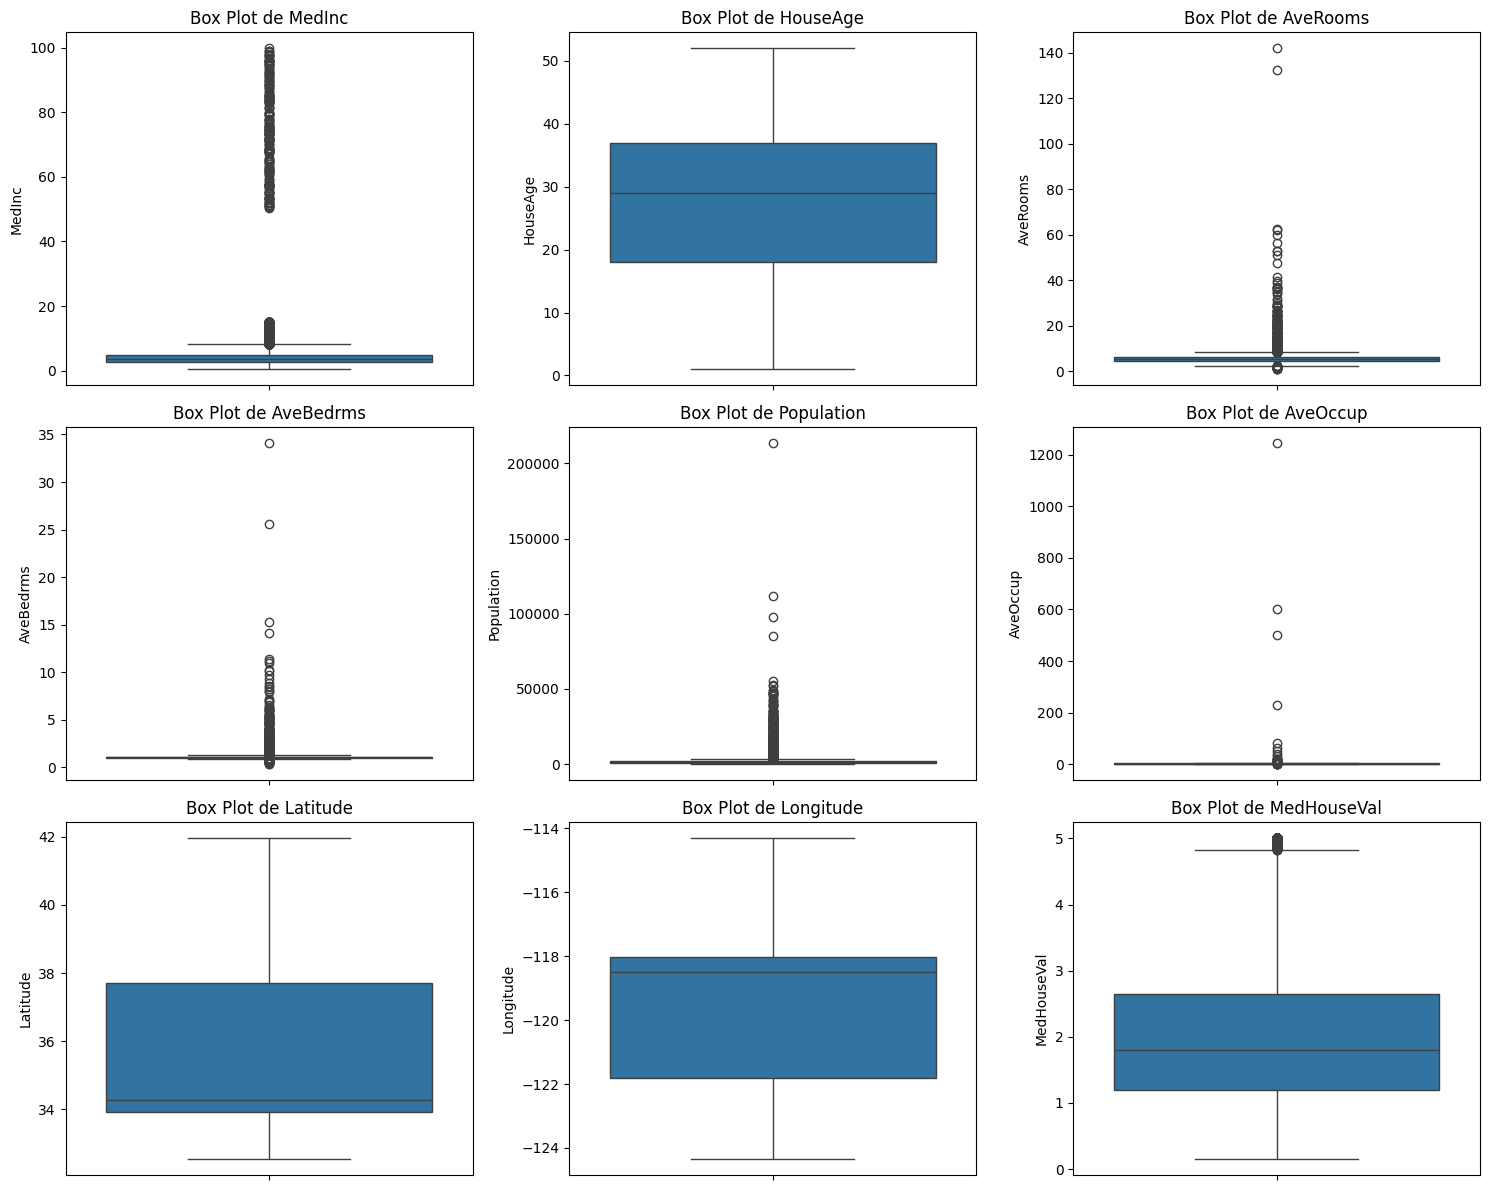

In [17]:
print("\n--- Visualisation des valeurs aberrantes (Outliers) dans TOUTES les colonnes numériques ---")

# Identifier toutes les colonnes numériques
# df.select_dtypes(include=np.number) sélectionne toutes les colonnes numériques
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

# Calculer le nombre de graphiques nécessaires et organiser la grille
n_plots = len(numerical_cols)
n_cols = 3 # Nombre de colonnes pour la grille de graphiques
n_rows = (n_plots + n_cols - 1) // n_cols # Calcul du nombre de lignes nécessaire

plt.figure(figsize=(n_cols * 5, n_rows * 4)) # Ajuster la taille globale de la figure

for i, col in enumerate(numerical_cols):
    plt.subplot(n_rows, n_cols, i + 1) # Positionner le subplot actuel
    sns.boxplot(y=df[col])
    plt.title(f'Box Plot de {col}')
    plt.ylabel(col)

plt.tight_layout() # Ajuster automatiquement les subplots pour éviter le chevauchement
plt.show()

# Anaylsez les graphiques : Des points s'étendent-ils loin des "moustaches" des boîtes ? Ce sont des outliers.


# **Étape 2 : nettoyage et préparation des données pour l'entraînement**

Maintenant que nous avons identifié les problèmes, il est temps de les corriger. Cette partie vous guidera à travers les étapes de nettoyage et de transformation des données pour les rendre prêtes à être utilisées par un modèle de Machine Learning.

Objectifs de cette partie :

- Séparer les features $(X)$ de la variable cible $(y)$.

- Diviser le dataset en ensembles d'entraînement et de test.

- Traiter les valeurs manquantes (imputation).

- Gérer les valeurs aberrantes (outliers).

- Standardiser les features numériques.

# **Étape 2.1 : séparation des features $(X)$ et de la variable cible $(y)$**
La première étape est de distinguer les variables d'entrée (features) de la variable que nous voulons prédire (cible).

**Tâches** : Identifiez les variables d'entrée et la variables de sortie puis créez deux objets (DataFrames ou Series) :
- $X$ contenant toutes les features.
- $y$ contenant la colonne de la variable cible.

In [22]:
print("\n--- Séparation des Features (X) et de la Cible (y) ---")
# TODO: Séparez la colonne de la variable cible du reste du DataFrame.
# La colonne de la variable cible deviendra 'y', le reste sera 'X'.

X = df.drop('MedHouseVal', axis=1)   # axis=1 pour spécifier que c'est une colonne
y = df['MedHouseVal']

print(f"Forme de X (features) : {X.shape}")
print(f"Forme de y (cible) : {y.shape}")


--- Séparation des Features (X) et de la Cible (y) ---



--- Séparation des Features (X) et de la Cible (y) ---


KeyError: "['median_house_value'] not found in axis"

# **Étape 2.2 : séparation des données en ensembles d'entraînement et de test**
Il est crucial de diviser les données en un ensemble d'entraînement (X_train, y_train) et un ensemble de test (X_test, y_test). Cela permet d'évaluer la capacité de généralisation de notre modèle sur des données qu'il n'a jamais vues.

**Tâche** : Utilisez `train_test_split` de `sklearn.model_selection` pour diviser $X$ et $y$.

- Utilisez test_size=0.2 (20% pour le test).
- Utilisez `random_state=42` pour garantir la reproductibilité des résultats.

In [ ]:
print("\n--- Division du Dataset en Ensembles d'Entraînement et de Test ---")
# TODO: Utilisez train_test_split.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)



print(f"Forme de X_train : {X_train.shape}")
print(f"Forme de X_test : {X_test.shape}")
print(f"Forme de y_train : {y_train.shape}")
print(f"Forme de y_test : {y_test.shape}")

# **Étape 2.3 : traitement des valeurs manquantes (imputation)**
Les algorithmes de Machine Learning ne peuvent généralement pas gérer les valeurs manquantes. Nous allons les remplacer par des valeurs estimées.

**Tâche** : utilisez `SimpleImputer` avec la stratégie median (médiane, moins sensible aux outliers que la moyenne) pour remplacer les valeurs manquantes des variables numériques.


In [ ]:
print("\n--- Traitement des Valeurs Manquantes (Imputation) ---")

# Identifier les colonnes numériques
numerical_cols = X_train.select_dtypes(include=np.number).columns.tolist()

print(f"Colonnes numériques à imputer : {numerical_cols}")

# Imputer numérique (médiane)
if len(numerical_cols) != 0:
  imputer_numerical = SimpleImputer(strategy='median')
  X_train[numerical_cols] = imputer_numerical.fit_transform(X_train[numerical_cols])  # Fit et transform pour l'entraînement
  X_test[numerical_cols] = imputer_numerical.transform(X_test[numerical_cols])  # Utiliser transform pour le test !



print("\nNombre de NaNs après imputation (X_train) :")
print(X_train.isnull().sum().sum()) # Devrait être 0
print("Nombre de NaNs après imputation (X_test) :")
print(X_test.isnull().sum().sum()) # Devrait être 0

# **Étape 2.4 : traitement des valeurs aberrantes (outliers) numériques**

Bien que l'imputation par la médiane aide, les outliers peuvent impacter les performances des modèles. Une stratégie simple consiste à appliquer du capping, c’est-à-dire à limiter les valeurs extrêmes au-delà d’un certain seuil.

**Tâche** : Pour MedInc et Population, identifiez les quartiles $(Q1, Q3)$ et l'intervalle interquartile $(IQR)$. Limitez les valeurs au-delà de $Q1 - 1.5*IQR$ et $Q3 + 1.5*IQR$.

In [ ]:
print("\n--- Gestion des Valeurs Aberrantes (Outliers) Numériques ---")

# Colonnes avec outliers à traiter
outlier_cols = ['MedInc', 'Population']

for col in outlier_cols:
    Q1 = X_train[col].quantile(0.25)
    Q3 = X_train[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Capper les valeurs extrêmes en utilisant la fonction np.clip
    X_train[col] = np.clip(X_train[col], lower_bound, upper_bound)
    X_test[col] = np.clip(X_test[col], lower_bound, upper_bound)  # Appliquer les mêmes bornes au test

    print(f"Outliers traités pour la colonne '{col}' avec bornes [{lower_bound:.2f}, {upper_bound:.2f}]")

# Vérification visuelle après écrêtage (facultatif, pour montrer l'effet)
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
sns.boxplot(y=X_train['MedInc'])
plt.title('Box Plot de MedInc après traitement des outliers')
plt.subplot(1, 2, 2)
sns.boxplot(y=X_train['Population'])
plt.title('Box Plot de Population après traitement des outliers')
plt.tight_layout()
plt.show()

# **Étape 2.5 : standardisation des variables numériques**
La standardisation (StandardScaler) ou la normalisation (MinMaxScaler) est souvent nécessaire pour les algorithmes qui sont sensibles aux échelles des features (ex: régression linéaire, SVM). La standardisation centre les données autour de 0 et les met à l’échelle pour que leur variance soit égale à 1.

**Tâche** : Appliquez `StandardScaler` à toutes les colonnes numériques de X_train et X_test.

In [ ]:
print("\n--- Standardisation des Features Numériques ---")


numerical_features_final = X_train.select_dtypes(include=np.number).columns.tolist()
scaler = StandardScaler()

X_train[numerical_features_final] = scaler.fit_transform(X_train[numerical_features_final])  # Fit et transform pour l'entraînement
X_test[numerical_features_final] = scaler.transform(X_test[numerical_features_final])  # Transform pour le test

print("\nAperçu de X_train après standardisation :")
print(X_train.head())
print(f"Forme finale de X_train : {X_train.shape}")
print(f"Forme finale de X_test : {X_test.shape}")

# **Partie 3 : entraînement et évaluation d'un modèle de régression**
Maintenant que nos données sont propres et structurées, nous pouvons passer à l'étape clé du Machine Learning : l'entraînement d'un modèle capable de prédire la valeur médiane des maisons. Nous utiliserons un modèle de régression linéaire.

**Objectifs de cette partie :**

- Entraîner un modèle de régression linéaire sur les données d'entraînement.
- Utiliser ce modèle pour faire des prédictions sur les données test.
- Évaluer les performances du modèle à l'aide de métriques de régression.
- Visualiser les résultats pour mieux comprendre le comportement du modèle.

# **Étape 3.1 : entraînement d'un modèle de régression linéaire**
La régression linéaire est un modèle simple mais puissant qui modélise la relation entre une variable dépendante (cible) et une ou plusieurs variables indépendantes (features) en ajustant une équation linéaire aux données observées.

**Tâche :**

- Importez la classe `LinearRegression` de `sklearn.linear_model`.
- Instanciez un objet `LinearRegression`.
- Entraînez le modèle sur X_train et y_train.

In [ ]:
print("\n--- Entraînement du Modèle de Régression Linéaire ---")

# TODO: Importer LinearRegression
from sklearn.linear_model import LinearRegression

# TODO: Instancier le modèle de régression linéaire
model = LinearRegression()

# TODO: Entraîner le modèle sur les données d'entraînement (X_train, y_train)

print("Entraînement du modèle...")
model.fit(X_train, y_train)
print("Modèle entraîné avec succès.")

# **Étape 3.2 : prédictions sur les données test**
Une fois le modèle entraîné, nous l'utilisons pour faire des prédictions sur l'ensemble de test (X_test), qui contient des données que le modèle n'a jamais vues. C'est essentiel pour évaluer sa capacité à généraliser.

**Tâche :** Utilisez la méthode `.predict()` de votre modèle entraîné pour obtenir les prédictions sur X_test.

In [ ]:
print("\n--- Prédictions sur l'Ensemble de Test ---")

# TODO: Faire des prédictions sur X_test
y_pred = model.predict(X_test)


print("Prédictions générées.")
# Afficher les 5 premières prédictions et les 5 premières vraies valeurs pour comparaison
print("\nComparaison des 5 premières vraies valeurs et prédictions :")
comparison_df = pd.DataFrame({'Valeur Réelle': y_test.head(), 'Prédiction': y_pred[:5]})
print(comparison_df)

# **Étape 3.3 : évaluation des performances du modèle**
Pour évaluer la qualité de notre modèle de régression, nous utilisons diverses métriques qui quantifient l'écart entre les prédictions et les vraies valeurs.

**Tâche :**

- Importez les métriques `mean_absolute_error`, `mean_squared_error` et `r2_score` de sklearn.metrics.
- Calculez ces métriques en comparant y_test (les vraies valeurs) et y_pred (les prédictions).

In [36]:
print("\n--- Évaluation des Performances du Modèle ---")

# TODO: Importer les métriques nécessaires: mean_absolute_error, mean_squared_error, root_mean_squared_error, r2_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, root_mean_squared_error, r2_score

# TODO: Calculer le Mean Absolute Error (MAE)
mae = mean_absolute_error(y_test, y_pred)

print(f"Mean Absolute Error (MAE) : {mae:.2f}")

# TODO: Calculer le Mean Squared Error (MSE)
mse = mean_squared_error(y_test, y_pred)

print(f"Mean Squared Error (MSE) : {mse:.2f}")

# TODO: Calculer le Root Mean Squared Error (RMSE)
rmse = root_mean_squared_error(y_test, y_pred)
print(f"Root Mean Squared Error (RMSE) : {rmse:.2f}")

# TODO: Calculer le Coefficient de Détermination (R²)
r2 = r2_score(y_test, y_pred)

print(f"Coefficient de Détermination (R²) : {r2:.2f}")

# Discussion des métriques :
print("\nInterprétation des métriques :")
print("\t- MAE : Erreur moyenne absolue entre les prédictions et les vraies valeurs (dans la même unité que la cible). Plus c'est bas, mieux c'est.")
print("\t- MSE / RMSE : Mesurent l'ampleur des erreurs. Le RMSE est souvent préféré car il est dans la même unité que la cible et pénalise davantage les erreurs importantes.")
print("\t- R² : Représente la proportion de la variance de la variable dépendante qui est expliquée par les variables indépendantes du modèle. Plus il est proche de 1, mieux le modèle explique la variance.")



--- Évaluation des Performances du Modèle ---
Mean Absolute Error (MAE) : 0.56
Mean Squared Error (MSE) : 0.60
Root Mean Squared Error (RMSE) : 0.78
Coefficient de Détermination (R²) : 0.54

Interprétation des métriques :
	- MAE : Erreur moyenne absolue entre les prédictions et les vraies valeurs (dans la même unité que la cible). Plus c'est bas, mieux c'est.
	- MSE / RMSE : Mesurent l'ampleur des erreurs. Le RMSE est souvent préféré car il est dans la même unité que la cible et pénalise davantage les erreurs importantes.
	- R² : Représente la proportion de la variance de la variable dépendante qui est expliquée par les variables indépendantes du modèle. Plus il est proche de 1, mieux le modèle explique la variance.


# **Étape 3.4 : visualisation des résultats du modèle**
Une visualisation des prédictions par rapport aux vraies valeurs peut offrir une compréhension intuitive de la performance du modèle.

**Tâche :**
- Créez un nuage de points (scatter plot) comparant y_test et y_pred.
- Idéalement, les points devraient s'aligner le long de la diagonale y_test = y_pred.


--- Visualisation des Prédictions vs. Vraies Valeurs ---


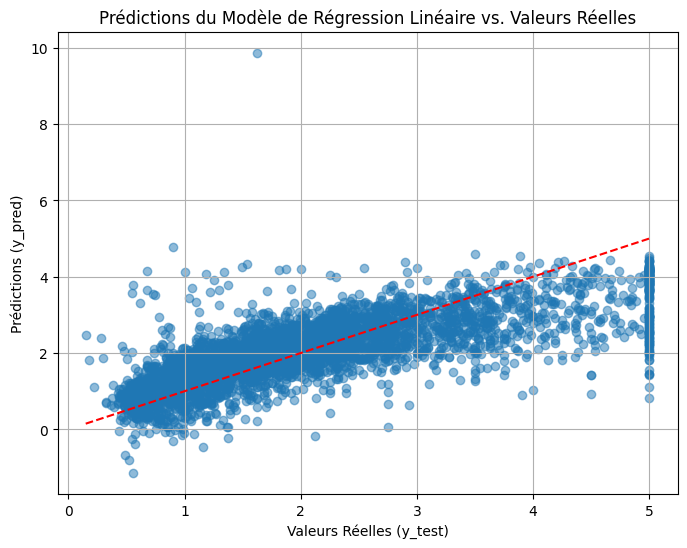

In [37]:
print("\n--- Visualisation des Prédictions vs. Vraies Valeurs ---")

plt.figure(figsize=(8, 6))
#TODO: Graphique les valeurs réelle versus les predict en utilisant plt.scatter
plt.scatter(y_test, y_pred, alpha=0.5)

#TODO:Graphique Ligne diagonale parfaite
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')
                                        # Ligne diagonale parfaite
plt.xlabel('Valeurs Réelles (y_test)')
plt.ylabel('Prédictions (y_pred)')
plt.title('Prédictions du Modèle de Régression Linéaire vs. Valeurs Réelles')
plt.grid(True)
plt.show()

# Anaylsez le graphique : Les points sont-ils proches de la ligne rouge ? Y a-t-il des patterns spécifiques ?

# **Synthèse de la modélisation et prochaines étapes**

Félicitations ! Vous avez entraîné votre premier modèle de régression linéaire, fait des prédictions et évalué ses performances dans un contexte de prédiction de prix immobiliers.

À ce stade, vous devriez être capable de :

- Charger et explorer un jeu de données.
- Identifier et résoudre des problèmes de qualité des données (NaNs, outliers).
- Préparer les données pour l'entraînement d'un modèle.
- Entraîner un modèle de régression.
- Évaluer la performance du modèle avec des métriques standards.
- Visualiser les résultats.

Ce TP vous a permis d'appliquer les phases standard d'un entraînement de modèle supervisé pour un problème de régression. Dans des projets futurs, vous pourriez explorer des modèles de régression plus avancés, optimiser les hyperparamètres, ou effectuer une ingénierie de fonctionnalités plus sophistiquée pour améliorer les performances.

# **Partie bonus : comparaison des performances de plusieurs modèles**

**scikit-learn** propose plusieurs méthodes d’apprentissage supervisé pour effectuer des tâches de régression. Dans cette partie, l’objectif est d’explorer d’autres modèles que la régression linéaire pour prédire le prix médian des biens immobiliers. Parmi les options disponibles, on trouve par exemple [SVM](https://scikit-learn.org/stable/api/sklearn.svm.html) (Support Vector Machines) ou [Random Forest](https://scikit-learn.org/stable/api/sklearn.ensemble.html).



**Tâche :** À partir de la documentation de scikit-learn et des étapes précédentes, entraînez un modèle de type Random Forest ou SVM. Comparez ensuite ses performances à celles obtenues avec la régression linéaire, et analysez les résultats en commentant les différences observées.

